---
title: "Practice Activity 3-1: Concatenating, Joining, Pivoting"
author: "Shiqi Wu"
format:
  html:
    theme: cosmo
    embed-resources: true
execute:
  echo: true
---

# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [127]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [128]:
data_dir = "https://dlsun.github.io/pods/data/ml-1m/"

In [129]:
movies = pd.read_csv(data_dir + "movies.dat",sep="::",engine="python",header=None,names=["MovieID", "Title", "Genres"],encoding_errors="ignore")

movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [130]:
ratings = pd.read_csv(data_dir + "ratings.dat",sep="::",engine="python",header=None,names=["UserID", "MovieID", "Rating", "Timestamp"])

ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [131]:
users = pd.read_csv(data_dir + "users.dat",sep="::",engine="python",header=None,names=["UserID", "Gender", "Age", "Occupation", "Zip-code"],dtype={"Zip-code": str})

users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [132]:
ratings_users = ratings.merge(users, on="UserID")

ratings_users.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,1193,5,978300760,F,1,10,48067
1,1,661,3,978302109,F,1,10,48067
2,1,914,3,978301968,F,1,10,48067
3,1,3408,4,978300275,F,1,10,48067
4,1,2355,5,978824291,F,1,10,48067


In [133]:
age_ratings = ratings_users.groupby("Age")["Rating"].mean()

age_ratings

Age
1     3.549520
18    3.507573
25    3.545235
35    3.618162
45    3.638062
50    3.714512
56    3.766632
Name: Rating, dtype: float64

Answer: Users aged 56 and older give the highest average rating, about 3.77 out of 5.

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [134]:
movie_summary = ratings.groupby("MovieID")["Rating"].agg(["count", "mean"])

In [135]:
movie_summary.head()

,count,mean
MovieID,,
1,2077,4.146846
2,701,3.201141
3,478,3.016736
4,170,2.729412
5,296,3.006757


In [136]:
movies_100 = movie_summary[movie_summary["count"] >= 100]

In [137]:
movies_100.head()

,count,mean
MovieID,,
1,2077,4.146846
2,701,3.201141
3,478,3.016736
4,170,2.729412
5,296,3.006757


In [138]:
movies_100_named = movies_100.merge(movies, on="MovieID")

In [139]:
movies_100_named.head()

,MovieID,count,mean,Title,Genres
0,1,2077,4.146846,Toy Story (1995),Animation|Children's|Comedy
1,2,701,3.201141,Jumanji (1995),Adventure|Children's|Fantasy
2,3,478,3.016736,Grumpier Old Men (1995),Comedy|Romance
3,4,170,2.729412,Waiting to Exhale (1995),Comedy|Drama
4,5,296,3.006757,Father of the Bride Part II (1995),Comedy


In [140]:
highest_rated = movies_100_named[movies_100_named["mean"] == movies_100_named["mean"].max()]

In [141]:
highest_rated

,MovieID,count,mean,Title,Genres
1021,2019,628,4.56051,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama


In [142]:
lowest_rated = movies_100_named[movies_100_named["mean"] == movies_100_named["mean"].min()]

In [143]:
lowest_rated

,MovieID,count,mean,Title,Genres
401,810,120,1.466667,Kazaam (1996),Children's|Comedy|Fantasy


Answer: Among movies with at least 100 ratings, Seven Samurai has the highest average rating, about 4.56. Kazaam has the lowest average rating, about 1.47.

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [144]:
ratings_users["age_18_24"] = ratings_users["Age"] == 18

In [145]:
ratings_users[["Age", "age_18_24"]].head()

,Age,age_18_24
0,1,False
1,1,False
2,1,False
3,1,False
4,1,False


In [146]:
movie_plot = ratings_users.groupby("MovieID")[["Rating", "age_18_24"]].mean()

In [147]:
movie_plot.head()

,Rating,age_18_24
MovieID,,
1,4.146846,0.215696
2,3.201141,0.219686
3,3.016736,0.223849
4,2.729412,0.229412
5,3.006757,0.219595


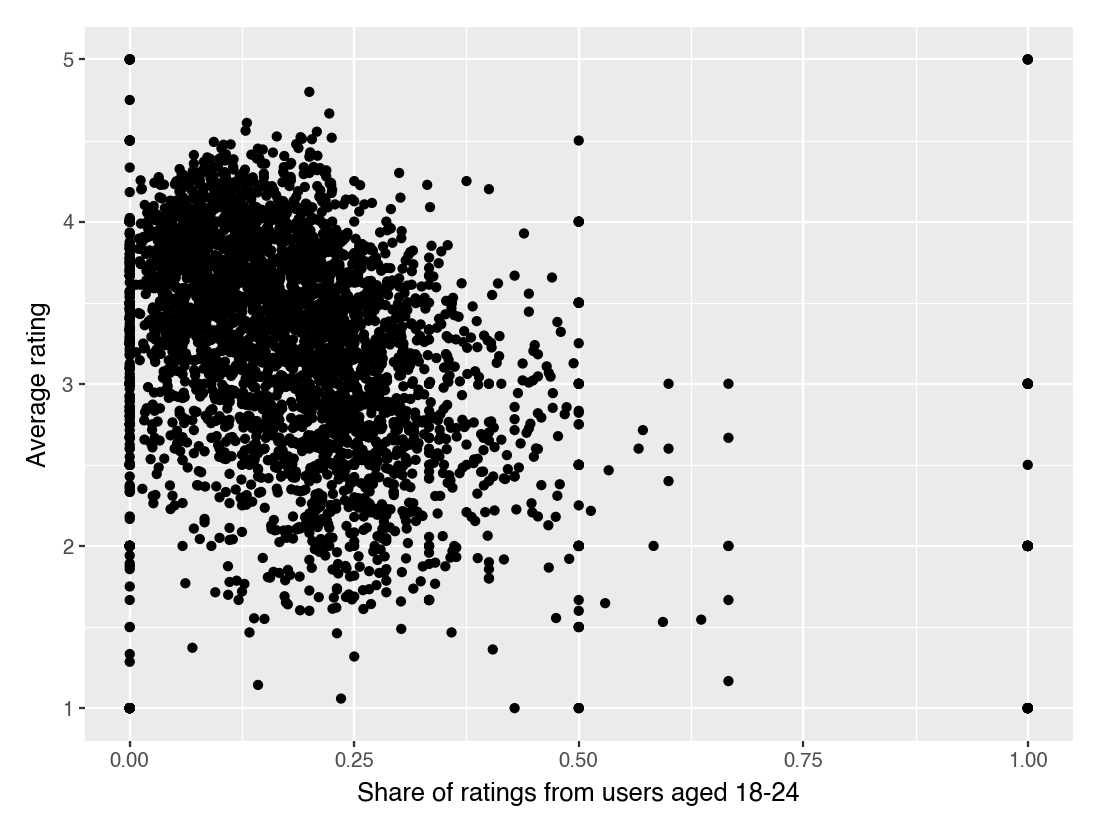

In [148]:
from plotnine import ggplot, aes, geom_point, labs

(
    ggplot(movie_plot, aes(x="age_18_24", y="Rating"))
    + geom_point()
    + labs(x="Share of ratings from users aged 18-24", y="Average rating")
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [149]:
movie_counts = movies.merge(movie_summary[["count"]], on="MovieID", how="left")

In [150]:
movie_counts.head()

,MovieID,Title,Genres,count
0,1,Toy Story (1995),Animation|Children's|Comedy,2077.0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,701.0
2,3,Grumpier Old Men (1995),Comedy|Romance,478.0
3,4,Waiting to Exhale (1995),Comedy|Drama,170.0
4,5,Father of the Bride Part II (1995),Comedy,296.0


In [151]:
movie_counts["count"] = movie_counts["count"].fillna(0)

In [152]:
(movie_counts["count"] == 0).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [153]:
ratings_1 = ratings[ratings["Rating"] == 1]

In [154]:
ratings_1.head()

,UserID,MovieID,Rating,Timestamp
148,2,21,1,978299839
180,2,3893,1,978299535
205,3,1261,1,978297663
249,4,3527,1,978294008
268,5,2916,1,978245645


In [155]:
counts_1 = ratings_1.groupby("MovieID")[["Rating"]].count()

In [156]:
counts_1.head()

,Rating
MovieID,
1,16
2,42
3,44
4,21
5,28


In [157]:
ratings_5 = ratings[ratings["Rating"] == 5]

In [158]:
counts_5 = ratings_5.groupby("MovieID")[["Rating"]].count()

In [159]:
counts_5.head()

,Rating
MovieID,
1,820
2,48
3,43
4,6
5,16


In [160]:
both_ratings = counts_1.merge(counts_5,on="MovieID",how="inner",suffixes=("_1", "_5"))

In [161]:
both_ratings.head()

,Rating_1,Rating_5
MovieID,,
1,16,820
2,42,48
3,44,43
4,21,6
5,28,16


In [162]:
len(both_ratings)

2986

In [163]:
both_ratings_named = both_ratings.merge(movies, on="MovieID")

In [165]:
from IPython.display import HTML, display

ratings_table = both_ratings_named[["Title", "Rating_1", "Rating_5"]]
display(ratings_table.head())

display(HTML(
    "<details><summary>Show all movies and rating counts</summary>"
    + ratings_table.to_html(index=False)
    + "</details>"
))

,Title,Rating_1,Rating_5
0,Toy Story (1995),16,820
1,Jumanji (1995),42,48
2,Grumpier Old Men (1995),44,43
3,Waiting to Exhale (1995),21,6
4,Father of the Bride Part II (1995),28,16


Title,Rating_1,Rating_5
Toy Story (1995),16,820
Jumanji (1995),42,48
Grumpier Old Men (1995),44,43
Waiting to Exhale (1995),21,6
Father of the Bride Part II (1995),28,16
Heat (1995),14,260
Sabrina (1995),18,61
Tom and Huck (1995),4,3
Sudden Death (1995),16,2
GoldenEye (1995),15,110
